In [29]:
 !pip install numpy opencv-python matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable


In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
from datetime import datetime, timedelta

In [54]:
# --- Settings --- 
video_path = '20241023_TrepS_01_in (2).MOV'
resize_rate = 0.2
sample_rate = 29
start_frame = 45000
start_time = datetime.strptime("23.10.2024 07:01:31", "%d.%m.%Y %H:%M:%S")
min_pixel_threshold = 50

In [55]:
# --- Open video ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    cap.release()
    raise FileNotFoundError(f"Failed to load video: {video_path}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Frames per Second: {fps}")
print(f"Total Frames: {total_frames}")
print(f"Starttime: {start_time}")
print(f"calculated Endtime: {start_time + timedelta(seconds=(total_frames/fps))}")

Frames per Second: 29
Total Frames: 66411
Starttime: 2024-10-23 07:01:31
calculated Endtime: 2024-10-23 07:39:41.034483


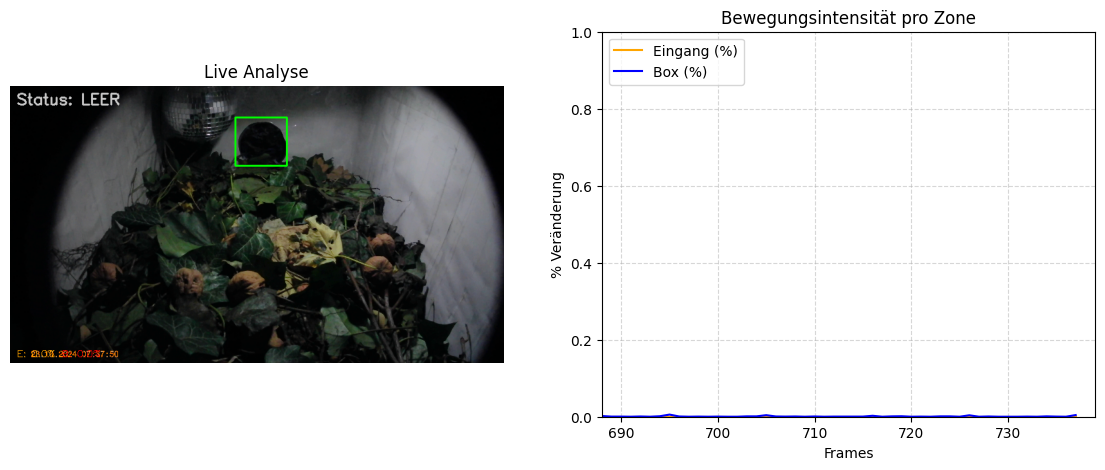

Starte Analyse...


Analysing:   0%|          | 0/739 [00:00<?, ?it/s]

Analyse abgeschlossen.


In [56]:
# Frame holen für Dimensionen
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
ret, temp_frame = cap.read()
if not ret: raise ValueError("Start frame not readable")

temp_frame = cv2.resize(temp_frame, (0, 0), fx=resize_rate, fy=resize_rate)
h, w = temp_frame.shape[:2]

# --- 3. MASKEN / POLYGON ---
# Deine Koordinaten
entrance_pts = np.array([
    [350, 50],   # Punkt 1 
    [430, 50],   # Punkt 2 
    [430, 125],  # Punkt 3 
    [350, 125]   # Punkt 4 
], np.int32)
entrance_pts = entrance_pts.reshape((-1, 1, 2))

mask_entrance = np.zeros((h, w), dtype=np.uint8)
cv2.fillPoly(mask_entrance, [entrance_pts], 255) 
mask_box = cv2.bitwise_not(mask_entrance) 

# WICHTIG: Gesamtpixel pro Zone berechnen für Prozentrechnung
total_pixels_ent = np.count_nonzero(mask_entrance)
total_pixels_box = np.count_nonzero(mask_box)
if total_pixels_ent == 0: total_pixels_ent = 1 # Div/0 Schutz

# --- 4. SETUP LIVE PLOT ---
plt.ioff()
fig, (ax_video, ax_graph) = plt.subplots(1, 2, figsize=(14, 5))

# A. Video (Links)
img_display = ax_video.imshow(cv2.cvtColor(temp_frame, cv2.COLOR_BGR2RGB))
ax_video.set_title("Live Analyse")
ax_video.axis('off')

# B. Graph (Rechts) - Jetzt mit Prozenten
x_data = [] 
y_ent_data = [] # Daten für Eingang
y_box_data = [] # Daten für Box

# Wir initialisieren zwei Linien
line_ent, = ax_graph.plot([], [], color='orange', label='Eingang (%)', linewidth=1.5)
line_box, = ax_graph.plot([], [], color='blue', label='Box (%)', linewidth=1.5)

ax_graph.set_title("Bewegungsintensität pro Zone")
ax_graph.set_xlabel("Frames")
ax_graph.set_ylabel("% Veränderung")
ax_graph.legend(loc='upper left')
ax_graph.grid(True, linestyle='--', alpha=0.5)
ax_graph.set_ylim(0, 5) # Start-Limit, passt sich später dynamisch an

display_handle = display(fig, display_id=True)

# --- 5. ANALYSE ---
backSub = cv2.createBackgroundSubtractorMOG2(history=10, varThreshold=50, detectShadows=False)

print("Starte Analyse...")
frame_counter = 0

for i in tqdm(range(start_frame, total_frames, sample_rate), desc="Analysing"):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if not ret: break
        
    # Resize
    frame_resized = cv2.resize(frame, (0, 0), fx=resize_rate, fy=resize_rate)
    
    # Background Subtraction
    fg_mask = backSub.apply(frame_resized)
    
    # Zonen Analyse
    motion_entrance_img = cv2.bitwise_and(fg_mask, fg_mask, mask=mask_entrance)
    count_entrance = np.sum(motion_entrance_img > 0)
    
    motion_box_img = cv2.bitwise_and(fg_mask, fg_mask, mask=mask_box)
    count_box = np.sum(motion_box_img > 0)
    
    # --- PROZENT BERECHNUNG ---
    # (Anzahl weiße Pixel / Gesamtpixel der Zone) * 100
    perc_ent = (count_entrance / total_pixels_ent) * 100
    perc_box = (count_box / total_pixels_box) * 100
    
    # Status Logik (nur für Text im Video)
    total_motion = count_entrance + count_box
    status_label = "LEER"
    color_bgr = (200, 200, 200)
    
    if total_motion > min_pixel_threshold:
        if count_box > count_entrance:
            status_label = "BOX"
            color_bgr = (0, 0, 255) # Rot
        else:
            status_label = "EINGANG"
            color_bgr = (0, 165, 255) # Orange

    # Daten sammeln
    x_data.append(frame_counter)
    y_ent_data.append(perc_ent)
    y_box_data.append(perc_box)
    frame_counter += 1

    # --- UPDATE VISUALISIERUNG ---
    if frame_counter % 2 == 0: 
        
        # 1. Video Update
        debug_frame = frame_resized.copy()
        cv2.polylines(debug_frame, [entrance_pts], True, (0, 255, 0), 2)
        cv2.putText(debug_frame, f"Status: {status_label}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_bgr, 2)
        
        # Prozentzahlen auch ins Video schreiben (optional, aber hilfreich)
        cv2.putText(debug_frame, f"E: {perc_ent:.1f}%", (10, h-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)
        cv2.putText(debug_frame, f"B: {perc_box:.1f}%", (80, h-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

        img_display.set_data(cv2.cvtColor(debug_frame, cv2.COLOR_BGR2RGB))
        
        # 2. Graph Update
        line_ent.set_data(x_data, y_ent_data)
        line_box.set_data(x_data, y_box_data)
        
        # X-Achse (Rolling Window 50 Frames)
        if len(x_data) > 50:
            current_window_x = x_data[-50:]
            current_window_y_ent = y_ent_data[-50:]
            current_window_y_box = y_box_data[-50:]
            ax_graph.set_xlim(current_window_x[0], current_window_x[-1] + 2)
        else:
            current_window_y_ent = y_ent_data
            current_window_y_box = y_box_data
            ax_graph.set_xlim(0, max(10, len(x_data)))
            
        # Y-Achse dynamisch skalieren (damit kleine Ausschläge sichtbar sind)
        max_val = max(max(current_window_y_ent, default=0), max(current_window_y_box, default=0))
        # Setze Limit auf Maximum + 20% Puffer, aber mindestens 1% (damit es bei 0 nicht crasht)
        ax_graph.set_ylim(0, max(1.0, max_val))
            
        display_handle.update(fig)

cap.release()
plt.close()
print("Analyse abgeschlossen.")

Erstelle finales Diagramm...


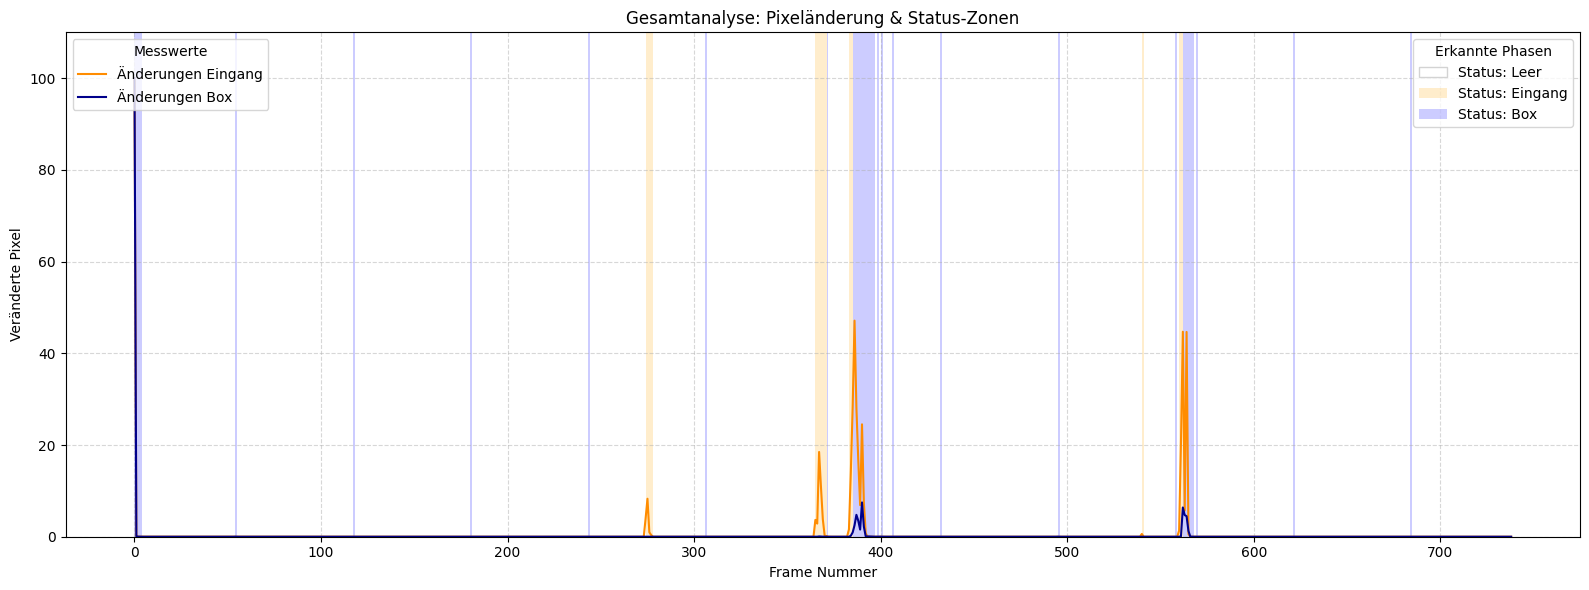

In [61]:
# --- 6. ABSCHLIESSENDES DIAGRAMM (Nach der Schleife) ---
print("Erstelle finales Diagramm...")

plt.figure(figsize=(16, 6))

# 1. Linien zeichnen (Bewegung in %)
# Wir nutzen x_data (Frame-Nummern) für die X-Achse
plt.plot(x_data, y_ent_data, color='darkorange', label='Änderungen Eingang', linewidth=1.5)
plt.plot(x_data, y_box_data, color='darkblue', label='Änderungen Box', linewidth=1.5)

# 2. Hintergrund-Zonen berechnen und zeichnen
# Algorithmus: Wir fassen identische aufeinanderfolgende Status-Werte zusammen
if len(y_data) > 0:
    current_status = y_data[0]
    start_x = x_data[0]
    
    # Farb-Mapping für die Zonen (Alpha wird später gesetzt)
    # Status 1 (Leer) bekommt KEINE Farbe, damit der Graph lesbar bleibt
    zone_colors = {
        1: None,          # Leer -> Weiß/Transparent
        2: 'orange',      # Eingang
        3: 'blue'         # Box
    }

    for i in range(1, len(y_data)):
        status = y_data[i]
        frame_idx = x_data[i]
        
        if status != current_status:
            # Der Status hat sich geändert -> Zeichne den alten Block
            color = zone_colors.get(current_status)
            if color is not None:
                plt.axvspan(start_x, frame_idx, color=color, alpha=0.2, lw=0)
            
            # Reset für den neuen Block
            current_status = status
            start_x = frame_idx
            
    # Den allerletzten Block nicht vergessen
    color = zone_colors.get(current_status)
    if color is not None:
        plt.axvspan(start_x, x_data[-1], color=color, alpha=0.2, lw=0)

# 3. Formatierung & Legenden
plt.title("Gesamtanalyse: Pixeländerung & Status-Zonen")
plt.xlabel("Frame Nummer")
plt.ylabel("Veränderte Pixel")
plt.grid(True, linestyle='--', alpha=0.5)

# Limits setzen (optional, damit Spitzen nicht den Graphen verzerren)
max_val = max(max(y_ent_data), max(y_box_data))
plt.ylim(0, max(1.0, max_val * 1.1)) 

# Legende 1: Die Linien (Standard)
legend1 = plt.legend(loc="upper left", title="Messwerte")
plt.gca().add_artist(legend1) # Wichtig, damit die erste Legende bleibt, wenn wir die zweite hinzufügen

# Legende 2: Die Farb-Zonen (Manuell erstellen)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='lightgray', label='Status: Leer'),
    Patch(facecolor='orange', alpha=0.2, label='Status: Eingang'),
    Patch(facecolor='blue', alpha=0.2, label='Status: Box')
]
plt.legend(handles=legend_elements, loc='upper right', title="Erkannte Phasen")

plt.tight_layout()
plt.savefig("diagram.png", dpi=300)
plt.show()